In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import SDP_miRNA.simulation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tqdm

In [2]:
rng = np.random.default_rng(867)

In [16]:
class GeneralBirthDeathOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, targets, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]"
        ]
        for i in range(targets):
            reactions += [
                "1",
                f"xs[{i + 1}]",
                f"xs[0] * xs[{i + 1}]"
            ]

        stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out = np.zeros((2 + targets * 3, 1 + targets))
        stoch_out[0, 0] = 1
        stoch_inp[1, 0] = 1
        for m in range(targets):
            r = 2 + 3 * m
            s = 1 + m
            stoch_out[r, s] = 1
            stoch_inp[r + 1, s] = 1
            stoch_inp[r + 2, 0] = 1
            stoch_inp[r + 2, s] = 1
            stoch_out[r + 2, 0] = 1

        vrs = stoch_out - stoch_inp
        db = 2
        R = len(reactions)
        S = 1 + targets
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

# Optimization scaling for large MRR model

M + R -> R

In [3]:
targets = 19
k_tx = 2
k_deg = 1
k_reg = 5

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
rates[0] = k_tx
stoch_inp[1, 0] = 1
rates[1] = k_deg

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    rates[r] = k_tx
    stoch_inp[r + 1, s] = 1
    rates[r + 1] = k_deg

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1
    rates[r + 2] = k_reg

In [4]:
initial = None
tmax = 10100
tmin = 100
tint = 10
n = 1000

# run gillespie
path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [5]:
# take samples at uniform time points
counts_OG = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=tmin, tmax=tmax, tint=tint, n=n)

In [6]:
# capture
mean_capture = 0.5
capture_shape = 30
capture_scale = (capture_shape / mean_capture) * (1 - mean_capture)

# sample capture
beta = rng.beta(capture_shape, capture_scale, size=n)

# downsample
counts_OG = counts_OG.astype(np.int64)
counts_OB = rng.binomial(counts_OG, beta[:, None])

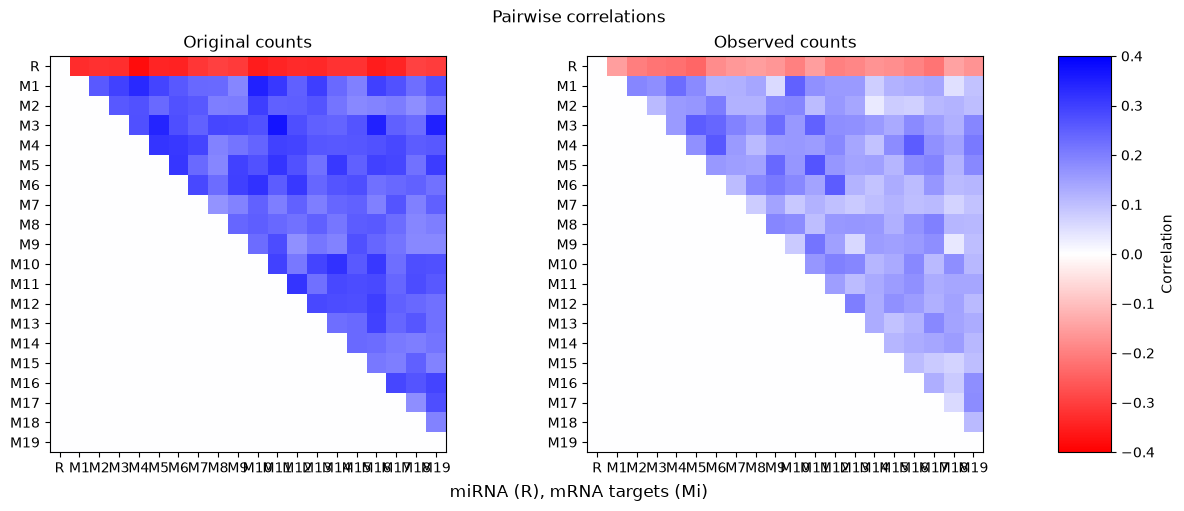

In [7]:
# compute original and observed data point correlations
correlation_matrix_original = np.corrcoef(counts_OG.T)
correlation_matrix_observed = np.corrcoef(counts_OB.T)

# remove redundant values
correlation_matrix_original[np.tril_indices(correlation_matrix_original.shape[0], k=0)] = 0
correlation_matrix_observed[np.tril_indices(correlation_matrix_observed.shape[0], k=0)] = 0

# display
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(targets)]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_observed, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original counts")
axs[0].set_xticks(range(targets + 1))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(targets + 1))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Observed counts")
axs[1].set_xticks(range(targets + 1))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(targets + 1))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("miRNA (R), mRNA targets (Mi)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

In [9]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    counts_OB,
    counts_OB,
    beta
)

In [10]:
# settings
max_opt_targets = 19
d = 3

# store results
opt_time_dict = {}
cut_time_dict = {}
cut_dict = {}
corr_dict = {}

for opt_targets in tqdm.tqdm(range(1, max_opt_targets + 1)):

    # set gene queries
    gene_queries = [
        [[t for t in range(1 + opt_targets)], []]
    ]
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d, tqdm_disable=True)

    # optimize
    BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_targets, d=d, tqdm_disable=True)
    BD_opt.analyse_dataset()

    # construct recovered correlations
    correlation_matrix_recovered = np.zeros((1 + targets, 1 + targets))
    for i in range(1 + opt_targets):
        for j in range(i + 1, 1 + opt_targets):
            correlation_matrix_recovered[i, j] = BD_opt.compute_dataset_correlation(i, j)[0]

    opt_time_dict[opt_targets] = BD_opt.result_dict[0]['time']
    cut_time_dict[opt_targets] = sum(BD_opt.cut_times_dict[0])
    cut_dict[opt_targets] = BD_opt.result_dict[0]['cuts']
    corr_dict[opt_targets] = correlation_matrix_recovered

100%|██████████| 19/19 [02:55<00:00,  9.26s/it]


In [14]:
BD_opt.silent = False
BD_opt.analyse_dataset()

Set parameter Username
Set parameter LicenseID to value 2848486
Academic license - for non-commercial use only - expires 2027-07-27
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 7 255U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 3544 rows, 1830 columns and 4424 nonzeros (Min)
Model fingerprint: 0x97169c2c
Model has 0 linear objective coefficients
Model has 231 quadratic constraints
Coefficient statistics:
  Matrix range     [2e-03, 1e+00]
  QMatrix range    [1e+00, 2e+00]
  Objective range  [0e+00, 0e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-03, 6e+00]

Presolve removed 3486 rows and 1334 columns

Continuous model is non-convex -- solving as a MIP


Presolve removed 3429 rows and 1335 columns
Presolve time: 0.01s
Presolved: 5126 r

Text(0.5, 0.98, 'Optimization scaling with species')

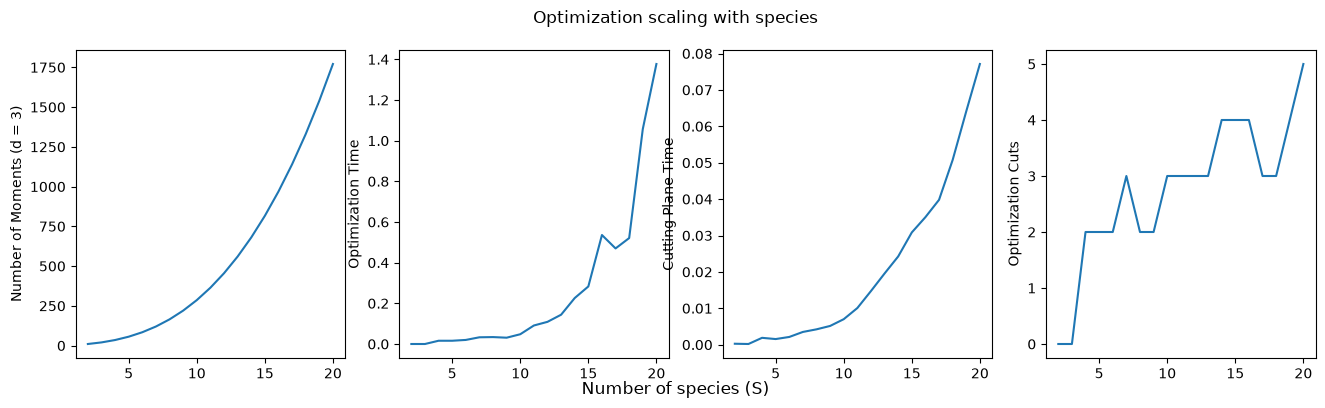

In [18]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
xs = [int(x) for x in range(2, max_opt_targets + 2)]
variables = [SDP_miRNA.utils.compute_Nd(S, d) for S in xs]
opt_times = opt_time_dict.values()
cut_times = cut_time_dict.values()
cuts = cut_dict.values()
axs[0].plot(xs, variables)
axs[0].set_ylabel("Number of Moments (d = 3)")
axs[1].plot(xs, opt_times)
axs[1].set_ylabel("Optimization Time")
axs[2].plot(xs, cut_times)
axs[2].set_ylabel("Cutting Plane Time")
axs[3].plot(xs, cuts)
axs[3].set_ylabel("Optimization Cuts")
fig.supxlabel("Number of species (S)")
fig.suptitle("Optimization scaling with species")

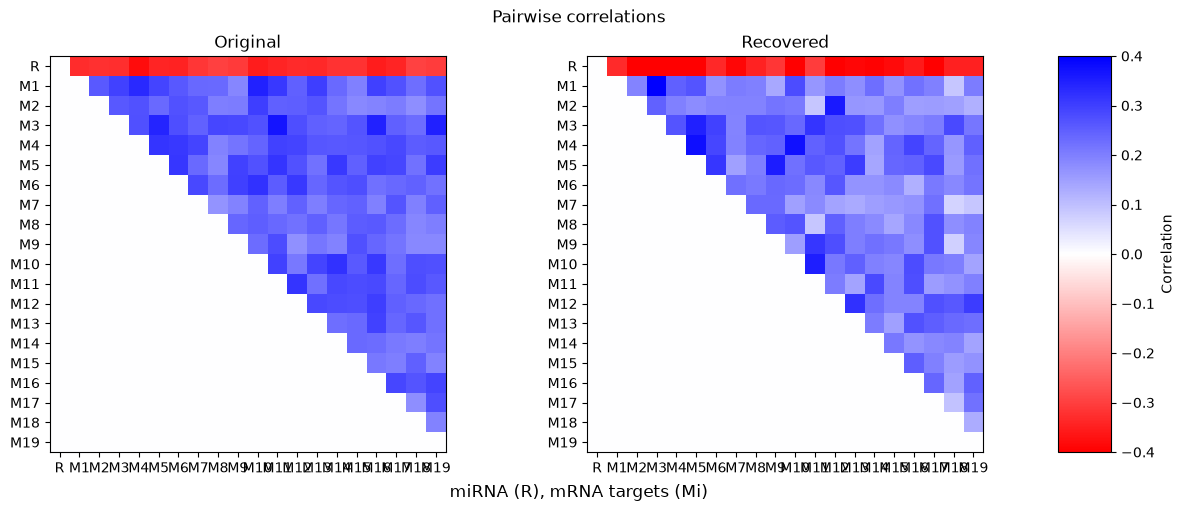

In [19]:
# select matrix
correlation_matrix_recovered = corr_dict[19]

# display
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(targets)]
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(correlation_matrix_original, cmap=cmap, vmin=-0.4, vmax=0.4)
im = axs[1].imshow(correlation_matrix_recovered, cmap=cmap, vmin=-0.4, vmax=0.4)
axs[0].set_title("Original")
axs[0].set_xticks(range(targets + 1))
axs[0].set_xticklabels(RNA_labels)
axs[0].set_yticks(range(targets + 1))
axs[0].set_yticklabels(RNA_labels)
axs[1].set_title("Recovered")
axs[1].set_xticks(range(targets + 1))
axs[1].set_xticklabels(RNA_labels)
axs[1].set_yticks(range(targets + 1))
axs[1].set_yticklabels(RNA_labels)
fig.suptitle("Pairwise correlations")
fig.supxlabel("miRNA (R), mRNA targets (Mi)")
plt.colorbar(im, cax=axs[2], label="Correlation")
plt.show()

# Optimization Scaling for Test Independent Data case

In [17]:
N = 1000
G = 100
counts = rng.poisson(2, size=(N, G))
beta = np.ones(N)

In [18]:
# construct dataset
data_SDP = SDP_miRNA.dataset.Dataset()

# duplicate full data (miRNA + mRNA) for easy indexing
data_SDP.construct_dataset_array(
    counts,
    counts,
    beta
)

In [7]:
# settings
G_list = [1, 2, 5, 10, 15, 20]
d = 3

# store results
opt_times = []
cut_times = []
cst_times = []
cuts = []

for opt_G in G_list:

    # set gene queries
    gene_queries = [
        [[t for t in range(opt_G)], []]
    ]
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # optimize
    BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_G - 1, d=d)
    BD_opt.analyse_dataset()

    opt_times.append(BD_opt.result_dict[0]['time'])
    cut_times.append(sum(BD_opt.cut_times_dict[0]))
    cst_times.append(BD_opt.construction_time)
    cuts.append(BD_opt.result_dict[0]['cuts'])

100%|██████████| 1/1 [00:00<00:00,  9.55it/s]


Variables: 0.000881195068359375
Moment Matrices 0.0005633831024169922
Moment Bounds 0.07058143615722656
    Overhead: 0.06974959373474121 (0.06949114799499512, 0.0002460479736328125, 1.1205673217773438e-05)
    Code: 6.9141387939453125e-06
    Adding: 0.0008211135864257812
Moment Equations 0.008912801742553711
    Code: 0.007077455520629883
    Adding: 0.0018260478973388672


100%|██████████| 1/1 [00:00<00:00, 16.06it/s]


Variables: 0.0005018711090087891
Moment Matrices 0.00029659271240234375
Moment Bounds 0.021961212158203125
    Overhead: 0.021340370178222656 (0.021103620529174805, 0.00022029876708984375, 1.5735626220703125e-05)
    Code: 6.9141387939453125e-06
    Adding: 0.0006079673767089844
Moment Equations 0.03007960319519043
    Code: 0.025760173797607422
    Adding: 0.004273176193237305


  0%|          | 0/1 [00:00<?, ?it/s]

...

Moment Equations 3.4816274642944336
    Code: 3.372370719909668
    Adding: 0.10892581939697266


  0%|          | 0/1 [00:00<?, ?it/s]

Variables: 0.0036017894744873047
Moment Matrices 0.8412408828735352
Moment Bounds 17.319030046463013
    Overhead: 17.24996018409729 (17.16936945915222, 0.014067411422729492, 0.06652188301086426)
    Code: 0.016458749771118164
    Adding: 0.052112579345703125


100%|██████████| 1/1 [00:32<00:00, 32.47s/it]

Moment Equations 14.236565589904785
    Code: 13.960238456726074
    Adding: 0.27555131912231445


In [8]:
BD_opt.analyse_dataset()

  0%|          | 0/1 [00:00<?, ?it/s]

Variables: 0.003184795379638672
Moment Matrices 1.0820057392120361
Moment Bounds 18.374972105026245
    Overhead: 18.30393671989441 (18.2205650806427, 0.014408111572265625, 0.06896209716796875)
    Code: 0.016501903533935547
    Adding: 0.05401873588562012


100%|██████████| 1/1 [00:33<00:00, 33.85s/it]

Moment Equations 14.322253465652466
    Code: 14.044328212738037
    Adding: 0.27713847160339355


Text(0.5, 0.98, 'Optimization scaling with species')

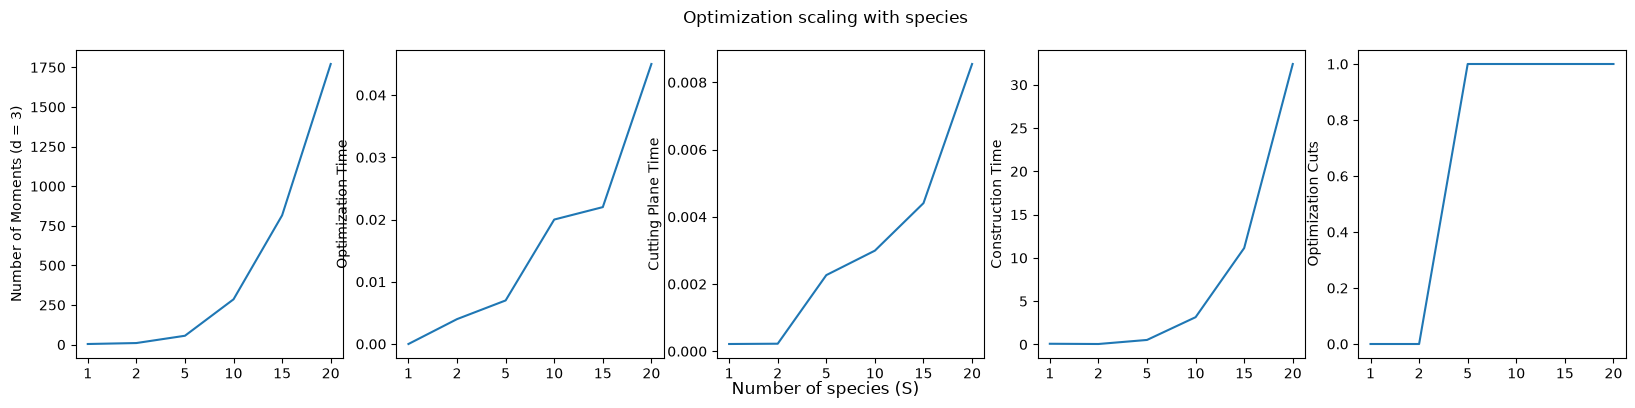

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
xs = range(len(G_list))
variables = [SDP_miRNA.utils.compute_Nd(opt_G, d) for opt_G in G_list]
axs[0].plot(xs, variables)
axs[0].set_ylabel("Number of Moments (d = 3)")
axs[0].set_xticks(xs)
axs[0].set_xticklabels(G_list)
axs[1].plot(xs, opt_times)
axs[1].set_ylabel("Optimization Time")
axs[1].set_xticks(xs)
axs[1].set_xticklabels(G_list)
axs[2].plot(xs, cut_times)
axs[2].set_ylabel("Cutting Plane Time")
axs[2].set_xticks(xs)
axs[2].set_xticklabels(G_list)
axs[3].plot(xs, cst_times)
axs[3].set_ylabel("Construction Time")
axs[3].set_xticks(xs)
axs[3].set_xticklabels(G_list)
axs[4].plot(xs, cuts)
axs[4].set_ylabel("Optimization Cuts")
axs[4].set_xticks(xs)
axs[4].set_xticklabels(G_list)
fig.supxlabel("Number of species (S)")
fig.suptitle("Optimization scaling with species")

## Improved code

In [10]:
# settings
G_list = [1, 2, 5, 10, 15, 20]
d = 3

# store results
opt_times_IMP = []
cut_times_IMP = []
cst_times_IMP = []
cuts_IMP = []

for opt_G in G_list:

    # set gene queries
    gene_queries = [
        [[t for t in range(opt_G)], []]
    ]
    data_SDP.gene_queries = gene_queries
    data_SDP.total_gene_queries = len(gene_queries)

    # bootstrap
    data_SDP.bootstrap(d=d)

    # optimize
    BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_G - 1, d=d)
    BD_opt.optimized_construction = True
    BD_opt.analyse_dataset()

    opt_times_IMP.append(BD_opt.result_dict[0]['time'])
    cut_times_IMP.append(sum(BD_opt.cut_times_dict[0]))
    cst_times_IMP.append(BD_opt.construction_time)
    cuts_IMP.append(BD_opt.result_dict[0]['cuts'])

100%|██████████| 1/1 [00:00<00:00, 82.86it/s]


Variables: 0.00025582313537597656
Moment Matrices 0.0001327991485595703
Moment Bounds 0.001434326171875
    Overhead: 0.0006892681121826172 (0.0005383491516113281, 0.00014162063598632812, 8.58306884765625e-06)
    Code: 1.0967254638671875e-05
    Adding: 0.0007240772247314453
Moment Equations 0.006554603576660156
    Code: 0.004515171051025391
    Adding: 0.002017498016357422


100%|██████████| 1/1 [00:00<00:00, 34.56it/s]


Variables: 0.000263214111328125
Moment Matrices 0.0005025863647460938
Moment Bounds 0.0019676685333251953
    Overhead: 0.0006811618804931641 (0.00048661231994628906, 0.00017213821411132812, 2.09808349609375e-05)
    Code: 1.2874603271484375e-05
    Adding: 0.0012614727020263672
Moment Equations 0.01941990852355957
    Code: 0.015144824981689453
    Adding: 0.004251718521118164


  0%|          | 0/1 [00:00<?, ?it/s]

...

Moment Equations 2.4069528579711914
    Code: 2.3018715381622314
    Adding: 0.10463237762451172


  0%|          | 0/1 [00:00<?, ?it/s]

Variables: 0.0020978450775146484
Moment Matrices 1.0023562908172607
Moment Bounds 0.16301774978637695
    Overhead: 0.08601784706115723 (0.020271778106689453, 0.00011610984802246094, 0.0656280517578125)
    Code: 0.017389297485351562
    Adding: 0.059043169021606445


100%|██████████| 1/1 [00:06<00:00,  6.35s/it]

Moment Equations 5.117410659790039
    Code: 4.92463755607605
    Adding: 0.1917734146118164


Text(0.5, 0.98, 'Optimization scaling with species')

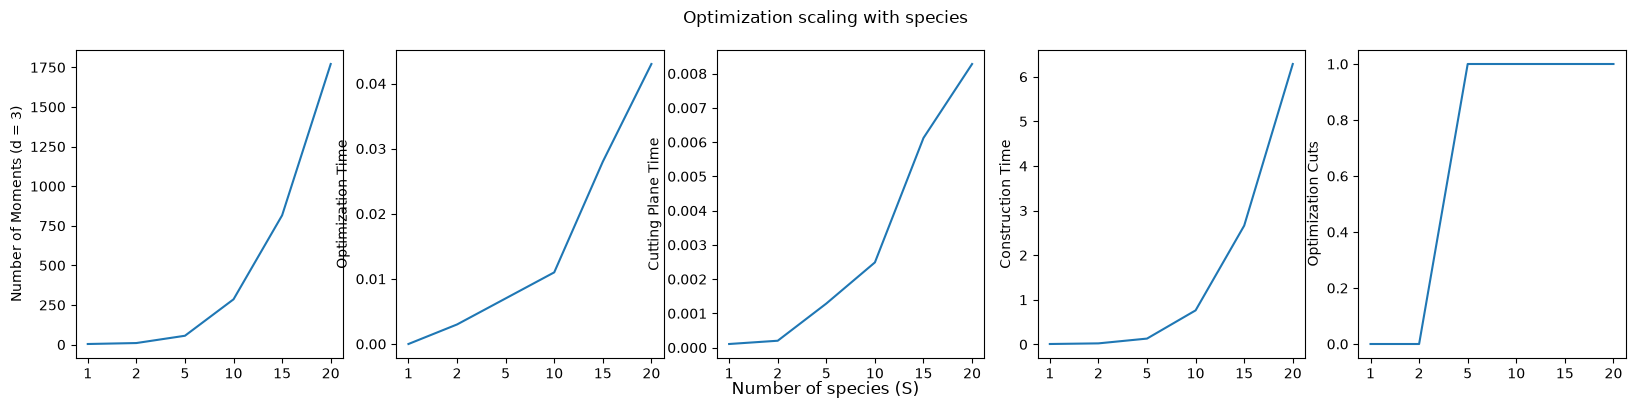

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
xs = range(len(G_list))
variables = [SDP_miRNA.utils.compute_Nd(opt_G, d) for opt_G in G_list]
axs[0].plot(xs, variables)
axs[0].set_ylabel("Number of Moments (d = 3)")
axs[0].set_xticks(xs)
axs[0].set_xticklabels(G_list)
axs[1].plot(xs, opt_times_IMP)
axs[1].set_ylabel("Optimization Time")
axs[1].set_xticks(xs)
axs[1].set_xticklabels(G_list)
axs[2].plot(xs, cut_times_IMP)
axs[2].set_ylabel("Cutting Plane Time")
axs[2].set_xticks(xs)
axs[2].set_xticklabels(G_list)
axs[3].plot(xs, cst_times_IMP)
axs[3].set_ylabel("Construction Time")
axs[3].set_xticks(xs)
axs[3].set_xticklabels(G_list)
axs[4].plot(xs, cuts_IMP)
axs[4].set_ylabel("Optimization Cuts")
axs[4].set_xticks(xs)
axs[4].set_xticklabels(G_list)
fig.supxlabel("Number of species (S)")
fig.suptitle("Optimization scaling with species")

In [22]:
opt_G = 50

# set gene queries
gene_queries = [
    [[t for t in range(opt_G)], []]
]
data_SDP.gene_queries = gene_queries
data_SDP.total_gene_queries = len(gene_queries)

# bootstrap
data_SDP.bootstrap(d=d)

# optimize
BD_opt = GeneralBirthDeathOptimization(data_SDP, opt_G - 1, d=d)
BD_opt.optimized_construction = True
BD_opt.analyse_dataset()

  0%|          | 0/1 [00:00<?, ?it/s]

Variables: 0.04096484184265137
Moment Matrices 574.4009938240051
Moment Bounds 29.592204093933105
    Overhead: 21.955622911453247 (0.739332914352417, 0.0011169910430908203, 21.21517038345337)
    Code: 6.201104640960693
    Adding: 1.4178698062896729
Moment Equations 164.56569170951843
    Code: 159.19178462028503
    Adding: 5.338829755783081


100%|██████████| 1/1 [12:56<00:00, 776.51s/it]


In [23]:
BD_opt.result_dict

{0: {'status': 'OPTIMAL', 'time': 6.966000080108643, 'cuts': 9}}

# Compute_B() Improvements

In [24]:
import math
import numpy as np
from functools import lru_cache
from collections import OrderedDict
from copy import copy


def compute_order(alpha):
    """Sum of elements of a power."""
    order = 0
    for alpha_i in alpha:
        order += alpha_i
    return order


def compute_Nd(S, d):
    """Number of moments of order <= d (S species)."""
    return math.factorial(S + d) // (math.factorial(d) * math.factorial(S))


def compute_powers_exact_order(S, d):
    """
    Compute the Nd powers of order <= d (S species), preserving the exact
    ordering of the original implementation while avoiding expensive repeated
    list-membership checks.
    """
    powers = [tuple(0 for _ in range(S))]
    powers_prev = [tuple(0 for _ in range(S))]

    for order in range(1, d + 1):
        seen = OrderedDict()
        for alpha in powers_prev:
            for i in range(S):
                alpha_new = list(alpha)
                alpha_new[i] += 1
                seen[tuple(alpha_new)] = None
        powers_current = list(seen.keys())
        powers.extend(powers_current)
        powers_prev = powers_current

    return powers


@lru_cache(None)
def stirling2(n, k):
    """Stirling number of the second kind."""
    if n == 0 and k == 0:
        return 1
    if n == 0 or k == 0 or k > n:
        return 0
    if k == 1 or k == n:
        return 1
    return k * stirling2(n - 1, k) + stirling2(n - 1, k - 1)


@lru_cache(None)
def stirling1_signed(n, k):
    """Signed Stirling number of the first kind."""
    if n == 0 and k == 0:
        return 1
    if n == 0 or k == 0 or k > n:
        return 0
    if n == k:
        return 1
    return stirling1_signed(n - 1, k - 1) - (n - 1) * stirling1_signed(n - 1, k)


@lru_cache(None)
def observed_species_terms(l):
    """
    Expand E[X^l] for X ~ Bin(n, p) as a polynomial in p and n:

        E[X^l] = sum_{k,m} coeff * p^k * n^m

    Returns a list of triples:
        (beta_power=k, x_power=m, coeff)
    """
    coeffs = {}
    for k in range(l + 1):
        s2 = stirling2(l, k)
        if s2 == 0:
            continue
        for m in range(k + 1):
            s1 = stirling1_signed(k, m)
            if s1 == 0:
                continue
            coeffs[(k, m)] = coeffs.get((k, m), 0) + s2 * s1

    return [(beta_pow, x_pow, coeff) for (beta_pow, x_pow), coeff in coeffs.items()]


def compute_B_optimized(beta, S, U, d):
    """
    Capture efficiency moment scaling matrix.

    This version preserves the exact powers ordering of the original
    compute_powers implementation, while avoiding SymPy polynomial algebra.

    Args:
        beta: per-cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) matrix of coefficients
    """
    U = set(U)

    # exact original ordering
    powers = compute_powers_exact_order(S, d)
    Nd = len(powers)
    power_to_idx = {alpha: i for i, alpha in enumerate(powers)}

    # beta moments
    y_beta = np.array([np.mean(beta ** l) for l in range(d + 1)], dtype=float)

    B = np.zeros((Nd, Nd), dtype=float)
    zero_power = (0,) * S

    for row, alpha in enumerate(powers):
        # map: (beta_power, xs_power_tuple) -> coefficient
        term_map = {(0, zero_power): 1.0}

        for i in range(S):
            a_i = alpha[i]

            if i in U:
                species_terms = [(0, a_i, 1.0)]
            else:
                species_terms = observed_species_terms(a_i)

            new_map = {}
            for (b0, xs0), c0 in term_map.items():
                for b1, x1, c1 in species_terms:
                    xs_new = list(xs0)
                    xs_new[i] += x1
                    xs_new = tuple(xs_new)

                    key = (b0 + b1, xs_new)
                    new_map[key] = new_map.get(key, 0.0) + c0 * c1

            term_map = new_map

        for (beta_power, xs_power), coeff in term_map.items():
            col = power_to_idx[xs_power]
            B[row, col] += coeff * y_beta[beta_power]

    return B

In [58]:
import scipy
from scipy.sparse import coo_matrix

def compute_B_optimized_sparse(beta, S, U, d):
    """
    Capture efficiency moment scaling matrix.

    This version preserves the exact powers ordering of the original
    compute_powers implementation, while avoiding SymPy polynomial algebra.
    It returns a SciPy CSR sparse matrix.

    Args:
        beta: per-cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) sparse CSR matrix of coefficients
    """
    U = set(U)

    # exact original ordering
    powers = compute_powers_exact_order(S, d)
    Nd = len(powers)
    power_to_idx = {alpha: i for i, alpha in enumerate(powers)}

    # beta moments
    y_beta = np.array([np.mean(beta ** l) for l in range(d + 1)], dtype=float)

    zero_power = (0,) * S
    rows = []
    cols = []
    data = []

    for row, alpha in enumerate(powers):
        # map: (beta_power, xs_power_tuple) -> coefficient
        term_map = {(0, zero_power): 1.0}

        for i in range(S):
            a_i = alpha[i]

            if i in U:
                species_terms = [(0, a_i, 1.0)]
            else:
                species_terms = observed_species_terms(a_i)

            new_map = {}
            for (b0, xs0), c0 in term_map.items():
                for b1, x1, c1 in species_terms:
                    xs_new = list(xs0)
                    xs_new[i] += x1
                    xs_new = tuple(xs_new)

                    key = (b0 + b1, xs_new)
                    new_map[key] = new_map.get(key, 0.0) + c0 * c1

            term_map = new_map

        row_accum = {}
        for (beta_power, xs_power), coeff in term_map.items():
            col = power_to_idx[xs_power]
            value = coeff * y_beta[beta_power]
            if value != 0:
                row_accum[col] = row_accum.get(col, 0.0) + value

        for col, value in row_accum.items():
            if value != 0:
                rows.append(row)
                cols.append(col)
                data.append(value)

    B = coo_matrix((data, (rows, cols)), shape=(Nd, Nd), dtype=float).tocsr()
    B.sum_duplicates()
    B.eliminate_zeros()
    return B

In [ ]:
# capture
mean_capture = 0.5
capture_shape = 30
capture_scale = (capture_shape / mean_capture) * (1 - mean_capture)
n = 1000

# sample capture
beta = rng.beta(capture_shape, capture_scale, size=n)

# settings
U = []
d = 3

## S = 20

- new functions signifiantly faster

In [68]:
S = 20

In [70]:
B_current = SDP_miRNA.optimization_utils.compute_B(beta, S, U, d)

In [71]:
B_new = compute_B_optimized(beta, S, U, d)

In [72]:
B_sparse = compute_B_optimized_sparse(beta, S, U, d)

In [41]:
(B_current == B_new).all()

np.True_

In [73]:
# check equality by showing 0 non-zero entries in difference
(scipy.sparse.csr_matrix(B_new) - B_sparse).nnz == 0

True

## S = 50

- still very fast

In [78]:
S = 50

In [79]:
B_new = compute_B_optimized(beta, S, U, d)

In [80]:
B_sparse = compute_B_optimized_sparse(beta, S, U, d)

In [81]:
# check equality by showing 0 non-zero entries in difference
(scipy.sparse.csr_matrix(B_new) - B_sparse).nnz == 0

True

## S = 100

- new function runs out of memory, but sparse works well (although starts to slow down)

In [85]:
S = 100

In [91]:
try:
    B_new = compute_B_optimized(beta, S, U, d)
except Exception as e:
    print(e)

Unable to allocate 233. GiB for an array with shape (176851, 176851) and data type float64


In [87]:
B_sparse = compute_B_optimized_sparse(beta, S, U, d)

In [88]:
B_sparse.shape

(176851, 176851)

# Compute_A() Improvements

In [108]:
import math
import numpy as np
from functools import lru_cache
from collections import OrderedDict
from scipy.sparse import coo_matrix
import sympy as sp

@lru_cache(None)
def multinomial_poly_terms(alpha_tuple, shift_tuple):
    """
    Expand prod_i (x_i + shift_i)^alpha_i as a polynomial in x.

    Returns a dict:
        xs_power_tuple -> coefficient
    """
    S = len(alpha_tuple)
    term_map = {tuple(0 for _ in range(S)): 1}

    for i in range(S):
        a_i = alpha_tuple[i]
        v_i = shift_tuple[i]

        species_terms = []
        for k in range(a_i + 1):
            coeff = math.comb(a_i, k) * (v_i ** (a_i - k))
            if coeff != 0:
                power = [0] * S
                power[i] = k
                species_terms.append((tuple(power), coeff))

        new_map = {}
        for p0, c0 in term_map.items():
            for p1, c1 in species_terms:
                p_new = tuple(p0[j] + p1[j] for j in range(S))
                new_map[p_new] = new_map.get(p_new, 0) + c0 * c1
        term_map = new_map

    return term_map


@lru_cache(None)
def monomial_exponent_tuple(expr, xs_tuple):
    """Return exponent tuple for a monomial expression in xs_tuple."""
    powers = expr.as_powers_dict()
    return tuple(int(powers.get(x, 0)) for x in xs_tuple)



def parse_propensity_polynomial(expr, xs):
    """
    Parse a SymPy polynomial expression into a dict:
        xs_power_tuple -> coefficient
    """
    poly = sp.Poly(sp.expand(expr), *xs)
    return {tuple(mon): coeff for mon, coeff in zip(poly.monoms(), poly.coeffs()) if coeff != 0}



def compute_A_optimized(alpha, reactions, vrs, db, R, S, d):
    """
    Moment equation coefficient matrix.
    NOTE: must have order(alpha) <= d.

    This version preserves the exact powers ordering of the original
    compute_powers implementation, uses sparse output, replaces repeated
    linear searches by hash lookup, and avoids expanding the shifted monomial
    term separately for each reaction term.

    Args:
        alpha: moment order for equation (d/dt mu^alpha = 0)
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: array detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        d: maximum moment order used

    Returns:
        A: (R, Nd) sparse CSR matrix of coefficients
    """
    if compute_order(alpha) > d - db + 1:
        raise NotImplementedError(
            f"Maximum moment order {d} too small for moment equation of alpha = {alpha}: involves moments of higher order."
        )

    alpha = tuple(alpha)
    vrs = np.asarray(vrs)

    xs = sp.symbols([f'x{i}' for i in range(S)])

    powers = compute_powers_exact_order(S, d)
    Nd = len(powers)
    power_to_idx = {p: i for i, p in enumerate(powers)}

    x_alpha = tuple(alpha)

    rows = []
    cols = []
    data = []

    for r in range(R):
        prop_expr = sp.parse_expr(reactions[r], {'xs': xs})
        prop_terms = parse_propensity_polynomial(prop_expr, xs)

        shift = tuple(int(vrs[r, i]) for i in range(S))
        shifted_terms = multinomial_poly_terms(alpha, shift)

        delta_terms = dict(shifted_terms)
        delta_terms[x_alpha] = delta_terms.get(x_alpha, 0) - 1
        if delta_terms[x_alpha] == 0:
            del delta_terms[x_alpha]

        row_accum = {}
        for prop_power, prop_coeff in prop_terms.items():
            for delta_power, delta_coeff in delta_terms.items():
                total_power = tuple(prop_power[i] + delta_power[i] for i in range(S))
                col = power_to_idx[total_power]
                value = prop_coeff * delta_coeff
                row_accum[col] = row_accum.get(col, 0) + value

        for col, value in row_accum.items():
            if value != 0:
                rows.append(r)
                cols.append(col)
                data.append(float(value) if getattr(value, 'is_number', False) else value)

    A = coo_matrix((data, (rows, cols)), shape=(R, Nd)).tocsr()
    A.sum_duplicates()
    A.eliminate_zeros()
    return A

## S = 2

In [125]:
# settings
reactions = [
    "1",
    "xs[0]",
    "1",
    "xs[1]",
    "xs[0] * xs[1]"
]
vrs = np.array([
    [ 1,  0],
    [-1,  0],
    [ 0,  1],
    [ 0, -1],
    [-1, -1]
])
db = 2
R = 5
S = 2
d = 3
alpha = (1, 1)

In [126]:
A_current = SDP_miRNA.optimization_utils.compute_A(alpha, reactions, vrs, db, R, S, d)

In [127]:
A_new = compute_A_optimized(alpha, reactions, vrs, db, R, S, d)

In [128]:
(A_current == A_new.todense()).all()

np.True_

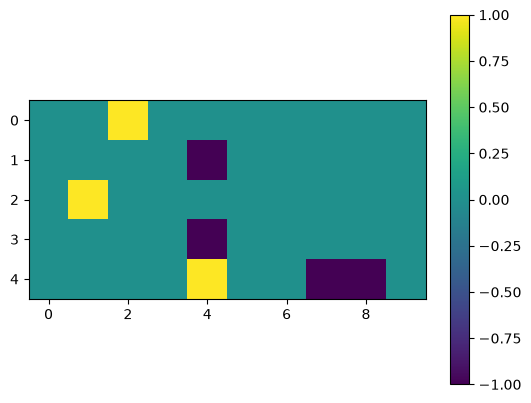

In [129]:
plt.imshow(A_current)
plt.colorbar()

## S = 20

In [140]:
# settings
targets = 19

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1
for m in range(targets):
    r = 2 + 3 * m
    s = 1 + m
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1

reactions = [
    "1",
    "xs[0]"
]
for i in range(targets):
    reactions += [
        "1",
        f"xs[{i + 1}]",
        f"xs[0] * xs[{i + 1}]"
    ]
vrs = stoch_out - stoch_inp
db = 2
R = len(reactions)
S = 1 + targets
d = 3
d_me = d - db + 1

In [ ]:
equal = True
for alpha in compute_powers_exact_order(S, d_me):
    A_current = SDP_miRNA.optimization_utils.compute_A(alpha, reactions, vrs, db, R, S, d)
    A_new = compute_A_optimized(alpha, reactions, vrs, db, R, S, d)
    equal = equal and (A_current == A_new.todense()).all()
equal

np.True_

In [154]:
for alpha in compute_powers_exact_order(S, d_me):
    A_current = SDP_miRNA.optimization_utils.compute_A(alpha, reactions, vrs, db, R, S, d)

In [155]:
for alpha in compute_powers_exact_order(S, d_me):
    A_new = compute_A_optimized(alpha, reactions, vrs, db, R, S, d)

## S = 50

In [156]:
# settings
targets = 50

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1
for m in range(targets):
    r = 2 + 3 * m
    s = 1 + m
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1

reactions = [
    "1",
    "xs[0]"
]
for i in range(targets):
    reactions += [
        "1",
        f"xs[{i + 1}]",
        f"xs[0] * xs[{i + 1}]"
    ]
vrs = stoch_out - stoch_inp
db = 2
R = len(reactions)
S = 1 + targets
d = 3
d_me = d - db + 1

In [157]:
for alpha in compute_powers_exact_order(S, d_me):
    A_new = compute_A_optimized(alpha, reactions, vrs, db, R, S, d)

In [158]:
A_new

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (152, 24804)>

In [160]:
R, compute_Nd(S, d)

(152, 24804)